# Ray tracing simulation # 

In [1]:
import os, importlib
import mitsuba as mi
print(mi.variants())

# mi.set_variant("llvm_ad_rgb")
mi.set_variant("llvm_ad_mono_polarized")

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, ITURadioMaterial

import sionna

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import util
import plot


['scalar_rgb', 'scalar_spectral', 'scalar_spectral_polarized', 'llvm_ad_rgb', 'llvm_ad_mono', 'llvm_ad_mono_polarized', 'llvm_ad_spectral', 'llvm_ad_spectral_polarized', 'cuda_ad_rgb', 'cuda_ad_mono', 'cuda_ad_mono_polarized', 'cuda_ad_spectral', 'cuda_ad_spectral_polarized']


In [4]:
# Import scene as xml file
scene = load_scene("SimpleConfig/SimpleConfig.xml")

scene.radio_materials["itu-concrete"].thickness = 0.1

# print("Available materials:", scene.radio_materials.keys())
# mat = scene.radio_materials["itu-concrete"]
# print(f"Material: {mat.name}")
# print(f"Conductivity: {mat.conductivity.numpy()} S/m")
# print(f"Relative Permittivity: {mat.relative_permittivity.numpy()}")
# print(f"Thickness: {mat.thickness.numpy()} m")

ground = ITURadioMaterial("ground",
                        "concrete",
                        thickness=1,
                        color=[0.011, 0.27, 0.8])

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

ground_object = scene.objects["elm__2"]
ground_object.radio_material = ground

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')

scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')

print(scene.rx_array.antenna_pattern.compute_gain())

tx = Transmitter("tx", [0, -2, 1])
# tx = Transmitter("tx", [-4, 8, 1])
scene.add(tx)

# Rx positions
x1, y1 = -7, 8
x2, y2 = 0, 8
x3, y3 = 7, 8
x4, y4 = 9, 0
x5, y5 = -9, 0
x6, y6 = -7, -8
x7, y7 = 0, -8
x8, y8 = 7, -8

RX_positions = [[x1, y1], [x2, y2], [x3, y3], [x4, y4], [x5, y5], [x6, y6], [x7, y7], [x8, y8]]

rx1 = Receiver("rx", [x1, y1, 1])
rx2 = Receiver("rx2", [x2, y2, 1])
rx3 = Receiver("rx3", [x3, y3, 1])
rx4 = Receiver("rx4", [x4, y4, 1])
rx5 = Receiver("rx5", [x5, y5, 1])
rx6 = Receiver("rx6", [x6, y6, 1])
rx7 = Receiver("rx7", [x7, y7, 1])
rx8 = Receiver("rx8", [x8, y8, 1])
scene.add(rx1)
scene.add(rx2)
scene.add(rx3)
scene.add(rx4)
scene.add(rx5)
scene.add(rx6)
scene.add(rx7)
scene.add(rx8)

scene.preview()

elm__2         itu-glass
no-name-3      itu-concrete
Directivity [dB]: 1.76
Gain [dB]: 1.76
Efficiency [%]: 1e+02
([1.49999], [1.5], [1.00001])


### Paths computations ###

In [37]:
pathSolver = PathSolver()
paths = pathSolver(scene=scene, max_depth=15)

# 1. Get current valid mask to know the correct shape
# This is crucial: 'valid' might have fewer dimensions than 'a'
original_valid_np = paths.valid.numpy()
target_shape = original_valid_np.shape

# 2. Get signal magnitude from 'a'
a_r, a_i = paths.a
a_r_np, a_i_np = a_r.numpy(), a_i.numpy()
magnitudes = np.sqrt(a_r_np**2 + a_i_np**2)

# 3. Reduce magnitude to match 'valid' shape
# If 'a' has extra antenna dimensions (dims 1 and 3), max over them
# Example: Convert [Rx, RxAnt, Tx, TxAnt, Paths] -> [Rx, Tx, Paths]
if len(magnitudes.shape) > len(target_shape):
    # Reduce dimensions 1 and 3 (antenna arrays) by taking the max power across antennas
    # Adjust axes based on your actual shape. Typically:
    # Axis 0=Rx, 1=RxAnt, 2=Tx, 3=TxAnt, 4=Paths
    reduced_magnitudes = np.max(magnitudes, axis=(1, 3)) 
else:
    reduced_magnitudes = magnitudes

# 4. Create the filter mask
# Keep paths where power is > 5% of peak
keep_mask = np.zeros(target_shape, dtype=bool)

# Iterate over Rx/Tx pairs to calculate local thresholds
for i in range(target_shape[0]): # Rx
    for j in range(target_shape[1]): # Tx
        # Get all paths for this link
        path_powers = reduced_magnitudes[i, j, :]
        max_val = np.max(path_powers)
        
        if max_val > 0:
            # Create boolean filter
            keep_mask[i, j, :] = path_powers >= (0.5 * max_val)

# 5. Combine with original validity (Logical AND)
# This ensures we don't accidentally "revive" non-existent paths
final_mask = keep_mask & original_valid_np

# 6. Apply to the internal _valid variable
# Use TensorXb (Extended Boolean Tensor)
paths._valid = mi.TensorXb(final_mask)

# 7. (Optional) Zero out 'a' for consistency
# You might need to broadcast the mask back to 'a's shape if they differ
paths._a = (
    mi.TensorXf(a_r_np * final_mask[:, None, :, None, :]), # Broadcast if needed
    mi.TensorXf(a_i_np * final_mask[:, None, :, None, :])
)


In [38]:
scene.preview(paths=paths)

In [26]:
angles = paths.phi_r
print(angles.shape)
for i in range(4):
    for j in range(len(angles[i, 0])):
        if final_mask[i, 0, j]:
            print(f"Receiver {i+1}, Path {j}: Angle = {angles[i, 0, j]*180/np.pi} degrees")

(8, 1, 399)
Receiver 1, Path 12: Angle = -56.5601 degrees
Receiver 1, Path 42: Angle = -71.0609 degrees
Receiver 1, Path 79: Angle = -28.5229 degrees
Receiver 1, Path 86: Angle = -28.5229 degrees
Receiver 1, Path 118: Angle = -20.2543 degrees
Receiver 2, Path 35: Angle = -124.992 degrees
Receiver 2, Path 157: Angle = -151.477 degrees
Receiver 3, Path 0: Angle = 40.6013 degrees
Receiver 4, Path 40: Angle = 164.544 degrees


(126,)
(126,)
(126,)
0.001
1e-13
8.30648e-15
1.293552e-14
1.2298417e-09
2.6169852e-14
1.2298417e-09
3.762984e-11


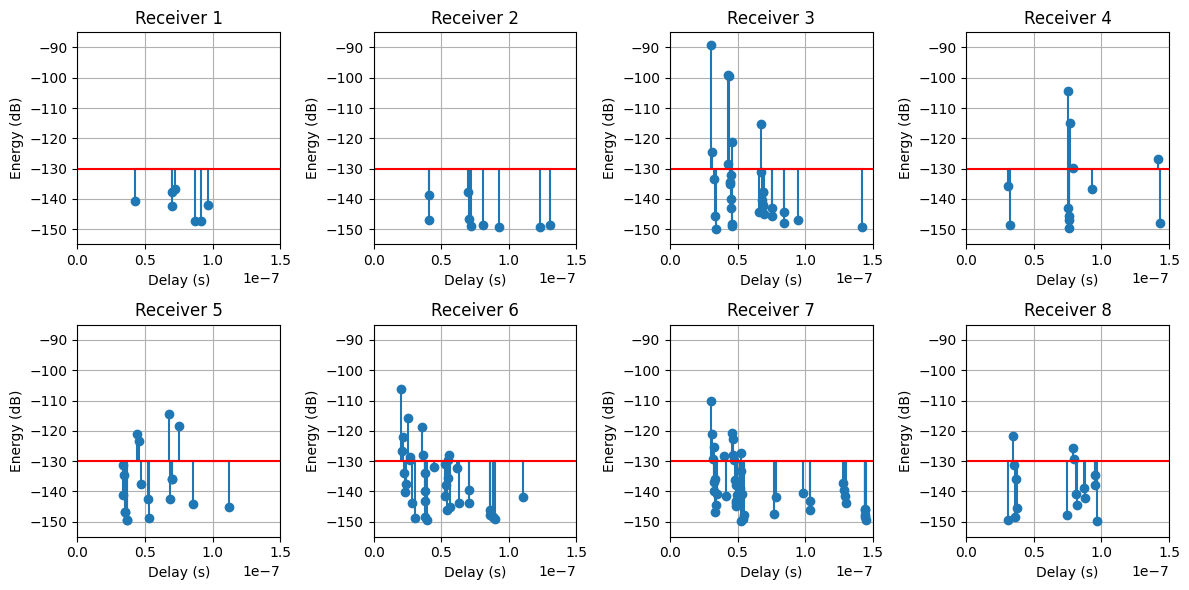

In [46]:
# Channel impulse response of the path
cir = paths.cir(sampling_frequency=3.5e9,
                num_time_steps=1,
                normalize_delays=False)


delays, magnitudes = util.format_cir(cir)
print(delays[0].shape)
print(magnitudes[0].shape)

# Energy of paths
energies = [magnitudes[i]**2 for i in range(8)]
print(energies[0].shape)

# Filtering out taps lower than the sensitivity theshold
P_TX_dBm = 0
P_TX_lin = 10 ** (P_TX_dBm / 10) / 1000  # Convert dBm to Watts
print(P_TX_lin)

S_RX_dBm = -100
S_RX_lin = 10 ** (S_RX_dBm / 10) / 1000  # Convert dBm to Watts
print(S_RX_lin)

for i in range(8):
    energies[i] = energies[i] * P_TX_lin
    mask = magnitudes[i] >= S_RX_lin
    delays[i] = delays[i][mask]
    magnitudes[i] = magnitudes[i][mask]
    energies[i] = energies[i][mask]

print(energies[0][np.argmin(delays[0])])
print(energies[1][np.argmin(delays[1])])
print(energies[2][np.argmin(delays[2])])
print(energies[3][np.argmin(delays[3])])

print(np.max(energies[2]))
print(np.max(energies[3]))

# Filter paths
threshold = -150 # in dB, relative to P_TX
threshold_lin = 10 ** (threshold / 10)

for i in range(8):
    mask = energies[i] >= threshold_lin
    delays[i] = delays[i][mask]
    magnitudes[i] = magnitudes[i][mask]
    energies[i] = energies[i][mask]


plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.stem(delays[i], 10*np.log10(energies[i]), bottom=10*np.log10(S_RX_lin))
    plt.axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
    plt.title(f"Receiver {i+1}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Energy (dB)")
    plt.xlim(0, 1.5e-7)
    plt.ylim(-155, -85)
    plt.grid()
plt.tight_layout()

(8, 26)


<Figure size 2000x2000 with 0 Axes>

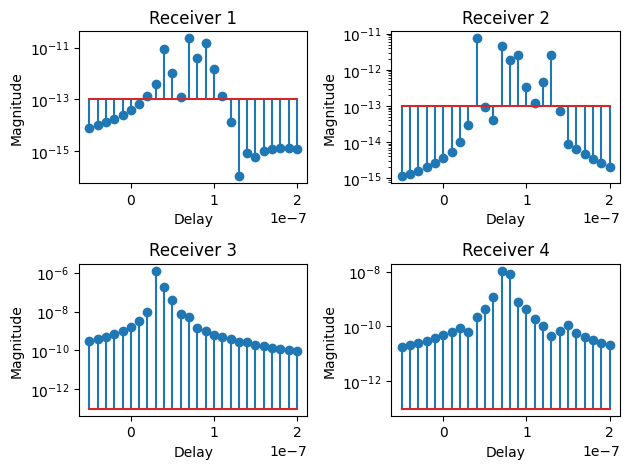

In [18]:
# Channel impulse response of the path
l_min, l_max = -5, 20
taps = paths.taps(bandwidth=100e6, l_min=l_min, l_max=l_max, normalize_delays=False)
times_taps = np.arange(l_min, l_max+1) / 100e6

taps_re, taps_im = taps[0], taps[1]
taps_mag = np.sqrt(taps_re.numpy()**2 + taps_im.numpy()**2)
taps_mag = taps_mag.reshape(taps_mag.shape[0], -1)
print(taps_mag.shape)

taps_energy = taps_mag ** 2


plt.figure(figsize=(20,20))
plt.subplots(2,2)

plt.subplot(2,2,1)
plt.stem(times_taps, taps_energy[0], bottom=S_RX_lin)
plt.title("Receiver 1")
plt.xlabel("Delay")
plt.ylabel("Magnitude")
plt.yscale('log')

plt.subplot(2,2,2)
plt.stem(times_taps,taps_energy[1], bottom=S_RX_lin)
plt.title("Receiver 2")
plt.xlabel("Delay")
plt.ylabel("Magnitude")
plt.yscale('log')

plt.subplot(2,2,3)
plt.stem(times_taps, taps_energy[2], bottom=S_RX_lin)
plt.title("Receiver 3")
plt.xlabel("Delay")
plt.ylabel("Magnitude")
plt.yscale('log')

plt.subplot(2,2,4)
plt.stem(times_taps, taps_energy[3], bottom=S_RX_lin)
plt.title("Receiver 4")
plt.xlabel("Delay")
plt.ylabel("Magnitude")
plt.yscale('log')

plt.tight_layout()
plt.show()

C:\Users\louis\AppData\Local\Temp\ipykernel_29368\1534243981.py:24: RuntimeWarning: invalid value encountered in log10
  plt.stem(first_taps[i], 10*np.log10(first_taps_mag[i]), linefmt='r-', markerfmt='ro', bottom=10*np.log10(S_RX_lin))


Estimated position: [-3.68984802 -1.99506084]
True position: [[0, -2, 1]]


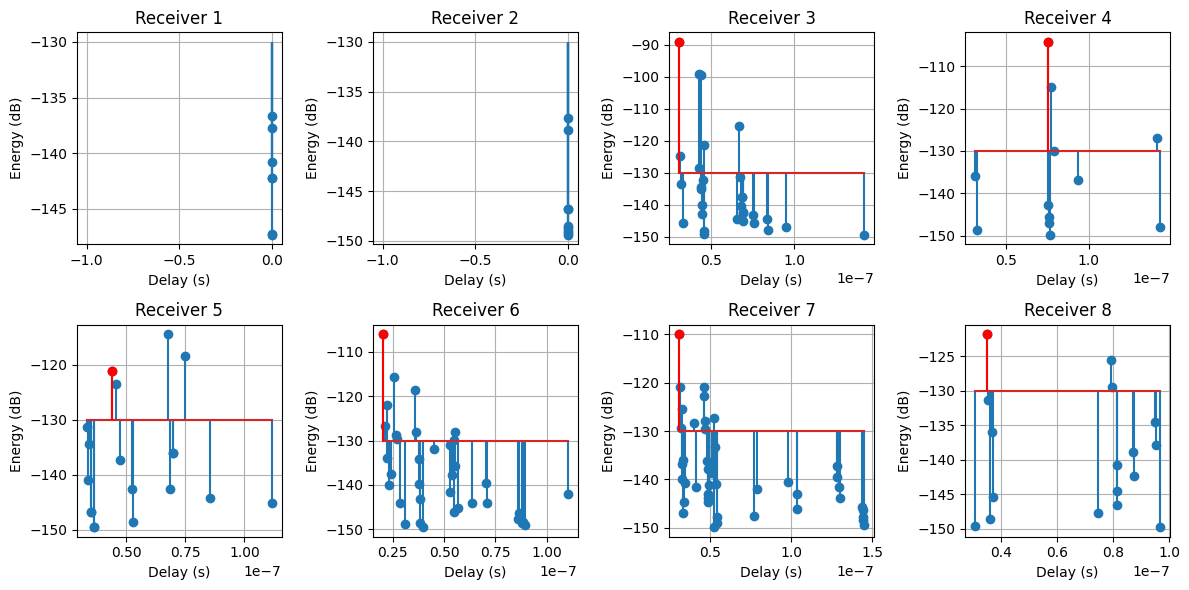

In [34]:
import Tdoa
import importlib

importlib.reload(Tdoa)
importlib.reload(util)

# Select TDOAs based on energy threshold

first_taps = -np.ones(8)
first_taps_mag = -np.ones(8)

for i in range(8):
    for j in range(len(energies[i])):
        if energies[i][j] >= S_RX_lin * 1e-0:
            first_taps[i] = delays[i][j]
            first_taps_mag[i] = energies[i][j]
            break


plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.stem(delays[i], 10*np.log10(energies[i]), bottom=10*np.log10(S_RX_lin))
    plt.stem(first_taps[i], 10*np.log10(first_taps_mag[i]), linefmt='r-', markerfmt='ro', bottom=10*np.log10(S_RX_lin))
    plt.title(f"Receiver {i+1}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Energy (dB)")
    plt.grid()
plt.tight_layout()

TdoaLocalizer = Tdoa.TdoaLocalization(first_taps, RX_positions)
position_estimate = TdoaLocalizer.localize()
print("Estimated position:", position_estimate)
print("True position:", tx.position)

  

<Figure size 2000x2000 with 0 Axes>

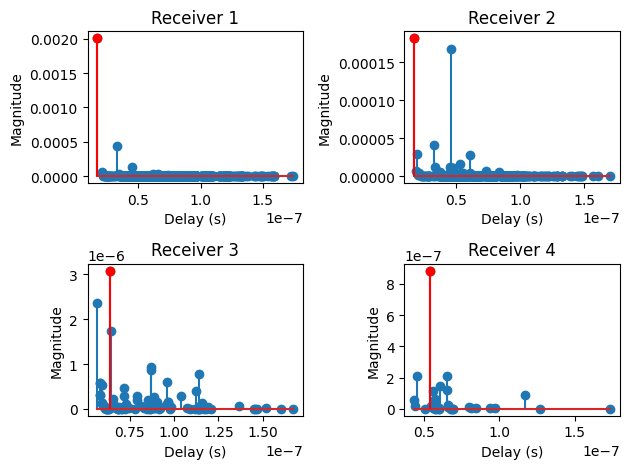

In [37]:
plt.figure(figsize=(20,20))
plt.subplots(2,2)

plt.subplot(2,2,1)
plt.stem(delays[0], magnitudes[0])
plt.stem(delays[0][np.argmax(magnitudes[0])], np.max(magnitudes[0]), linefmt='r-', markerfmt='ro', basefmt='r-')
plt.title("Receiver 1")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,2)
plt.stem(delays[1], magnitudes[1])
plt.stem(delays[1][np.argmax(magnitudes[1])], np.max(magnitudes[1]), linefmt='r-', markerfmt='ro', basefmt='r-')
plt.title("Receiver 2")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,3)
plt.stem(delays[2], magnitudes[2])
plt.stem(delays[2][np.argmax(magnitudes[2])], np.max(magnitudes[2]), linefmt='r-', markerfmt='ro', basefmt='r-')
plt.title("Receiver 3")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,4)
plt.stem(delays[3], magnitudes[3])
plt.stem(delays[3][np.argmax(magnitudes[3])], np.max(magnitudes[3]), linefmt='r-', markerfmt='ro', basefmt='r-')
plt.title("Receiver 4")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.tight_layout()
plt.show()